<a href="https://colab.research.google.com/github/HermesRoe/Food_prices_AI/blob/main/food_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# import pandas as pd
# from google.colab import files

# # 1. Load your current 1001-row file (Upload it to Colab first if needed)
# file_name = 'True_TamilNadu_Rice_Dataset_1001.xlsx'
# df = pd.read_excel(file_name)

# def refine_dataset(df):
#     # Ensure price is numeric
#     df['price'] = pd.to_numeric(df['price'], errors='coerce')

#     # ALGORITHM:
#     # Find rows where unit is '100 KG' OR price is unnaturally high (> 200)
#     # These are likely bulk prices that need to be converted to KG
#     mask = (df['unit'].astype(str).str.contains('100')) | (df['price'] > 200)

#     # Fix the price and the unit label
#     df.loc[mask, 'price'] = df.loc[mask, 'price'] / 100
#     df.loc[mask, 'unit'] = 'KG'

#     # Final cleanup: Ensure all units now say 'KG'
#     df['unit'] = 'KG'

#     return df

# # Apply the algorithm
# refined_df = refine_dataset(df)

# # 2. Save and Download
# final_file = "TamilNadu_Rice_Refined_Unit_Standardized.xlsx"
# refined_df.to_excel(final_file, index=False)

# print(f"Refinement Complete!")
# print(f"Total Rows: {len(refined_df)}")
# print(f"Price Range: ₹{refined_df['price'].min():.2f} - ₹{refined_df['price'].max():.2f}")

# files.download(final_file)

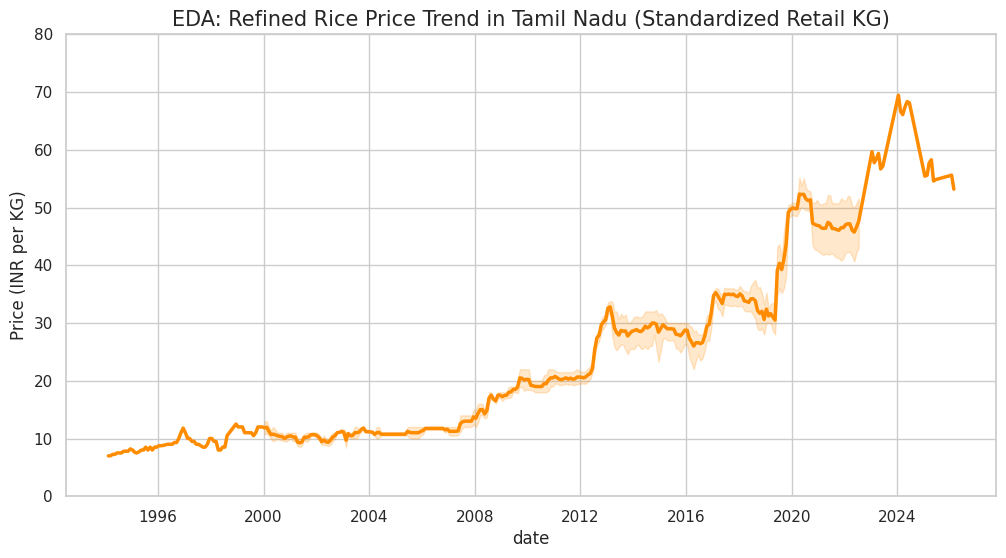

--- Market Forecast for Tamil Nadu ---
Predicted Price (2027): ₹52.87 / KG
Predicted Price (2030): ₹58.12 / KG


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Replace with your actual GitHub Raw Link
github_raw_url = 'https://github.com/HermesRoe/Food_prices_AI/blob/b92f3f7e8e0475bdd3d4e48f2a4612f696b06ab4/TamilNadu_Rice_Refined_Unit_Standardized.xlsx?raw=true'

try:
    # Load the 1001-row dataset directly from GitHub
    df = pd.read_excel(github_raw_url)

    # 2. THE UNIT REFINEMENT ALGORITHM
    # If unit is '100 KG' OR price is > 200, divide price by 100 and set unit to 'KG'
    mask = (df['unit'].astype(str).str.contains('100')) | (df['price'] > 200)
    df.loc[mask, 'price'] = df.loc[mask, 'price'] / 100
    df['unit'] = 'KG'

    # 3. SEABORN REPRESENTATION (Pictorial Analysis)
    df['date'] = pd.to_datetime(df['date'])
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    sns.lineplot(data=df, x='date', y='price', color='darkorange', linewidth=2.5)

    plt.title('EDA: Refined Rice Price Trend in Tamil Nadu (Standardized Retail KG)', fontsize=15)
    plt.ylabel('Price (INR per KG)')
    plt.ylim(0, 80) # Locks scale to human-readable retail levels
    plt.show()

    # 4. FUTURE FORECASTING (2027 & 2030)
    df['year_decimal'] = df['date'].dt.year + (df['date'].dt.month - 1) / 12.0
    model = LinearRegression().fit(df[['year_decimal']].values, df['price'].values)

    pred_2027 = model.predict([[2027.0]])[0]
    pred_2030 = model.predict([[2030.0]])[0]

    print(f"--- Market Forecast for Tamil Nadu ---")
    print(f"Predicted Price (2027): ₹{pred_2027:.2f} / KG")
    print(f"Predicted Price (2030): ₹{pred_2030:.2f} / KG")

except Exception as e:
    print("Error loading or refining data. Check your GitHub link!")
    print(e)